Political Speech Topic Modelling

In [1]:
# Install required libraries (run once)
# Uncomment if running for the first time
!pip install newsapi-python pyldavis plotly wordcloud matplotlib seaborn scikit-learn pandas -q
print("✅ Libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.8 MB/s eta 0:00:00
✅ Libraries ready


In [2]:
import os, json, re, warnings
from datetime import datetime, timedelta
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib import cm

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis
import pyLDAvis.lda_model

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "#0F1117",
    "axes.facecolor":   "#1A1D27",
    "axes.edgecolor":   "#2A2D3A",
    "axes.labelcolor":  "#E8EAF0",
    "xtick.color":      "#8B8FA8",
    "ytick.color":      "#8B8FA8",
    "text.color":       "#E8EAF0",
    "grid.color":       "#2A2D3A",
    "grid.linestyle":   "--",
    "axes.titlecolor":  "#E8EAF0",
    "axes.titlesize":   13,
    "font.family":      "monospace",
})

print("✅ Imports done")

✅ Imports done


## ⚙️ ConfigurationSet your NewsAPI key and parameters here. Everything else is automatic.

In [3]:
# ─────────────────────────────────────────────────────────────
#  CONFIGURATION  ← edit these
# ─────────────────────────────────────────────────────────────
NEWSAPI_KEY  = "76e09bb5bf5c4e6c91de5fe710313bf6"    # get free key at newsapi.org
CSV_FALLBACK = "REAL_political_data.csv"  # used if API quota is exhausted

LEADERS = {
    "Yogi Adityanath" : [
        "Yogi Adityanath", "Yogi Adityanath speech",
        "UP CM Yogi", "Adityanath government"
    ],
    "Asaduddin Owaisi": [
        "Asaduddin Owaisi", "Owaisi AIMIM",
        "Owaisi speech", "Owaisi parliament"
    ],
}

NUM_TOPICS   = 4          # topics per combined model
DAYS_BACK    = 30         # how many days of news to pull
PAGE_SIZE    = 100        # articles per query (max 100 for free tier)
DASHBOARD_OUT = "stakeholder_dashboard.html"
PYLDAVIS_OUT  = "interactive_topic_map.html"

# Domain vocabulary — maps LDA topics to human-readable domains
DOMAIN_VOCAB = {
    "Governance & Administration" : [
        "government","law","order","policy","scheme","administration",
        "infrastructure","development","project","fund","crore","launch"
    ],
    "Religious & Identity Politics" : [
        "hindu","muslim","religion","temple","mosque","jihad","community",
        "identity","culture","tradition","religious","minority","faith"
    ],
    "Electoral & Party Politics" : [
        "election","vote","campaign","rally","bjp","aimim","congress",
        "party","candidate","poll","seat","assembly","win","defeat"
    ],
    "Social Justice & Rights" : [
        "rights","justice","constitution","court","law","marginalised",
        "equality","discrimination","arrest","freedom","protest","demand"
    ],
    "Economic & Development" : [
        "economy","investment","employment","job","youth","education",
        "school","dropout","farmer","agriculture","gdp","growth","startup"
    ],
    "Security & Law Enforcement" : [
        "bulldozer","encounter","gangster","mafia","crime","arrest",
        "police","action","terror","infiltration","illegal","eviction"
    ],
}

print("✅ Configuration loaded")
print(f"   Leaders  : {list(LEADERS.keys())}")
print(f"   Topics   : {NUM_TOPICS}")
print(f"   Days back: {DAYS_BACK}")

✅ Configuration loaded
   Leaders  : ['Yogi Adityanath', 'Asaduddin Owaisi']
   Topics   : 4
   Days back: 30


## 📡 Step 1 — Data Collection via NewsAPI

In [4]:
def fetch_from_newsapi(api_key, leaders_dict, days_back=30, page_size=100):
    """Fetch headlines + descriptions for each leader from NewsAPI."""
    try:
        from newsapi import NewsApiClient
    except ImportError:
        print("⚠️  newsapi-python not installed. Run: pip install newsapi-python")
        return None

    client  = NewsApiClient(api_key=api_key)
    from_dt = (datetime.now() - timedelta(days=days_back)).strftime("%Y-%m-%d")
    records = []

    for leader, queries in leaders_dict.items():
        print(f"\n  Fetching for: {leader}")
        seen = set()
        for q in queries:
            try:
                resp = client.get_everything(
                    q=q, language="en",
                    from_param=from_dt,
                    sort_by="relevancy",
                    page_size=page_size,
                )
                articles = resp.get("articles", [])
                for art in articles:
                    title = art.get("title", "") or ""
                    desc  = art.get("description", "") or ""
                    text  = f"{title}. {desc}".strip()
                    if text not in seen and len(text) > 20:
                        seen.add(text)
                        records.append({
                            "Leader"           : leader,
                            "Text_For_Modeling": text,
                            "title"            : title,
                            "source"           : art.get("source", {}).get("name", ""),
                            "publishedAt"      : art.get("publishedAt", ""),
                        })
                print(f"    [{q}] → {len(articles)} articles")
            except Exception as e:
                print(f"    ⚠️  Error on query '{q}': {e}")

    return pd.DataFrame(records) if records else None


# ─────────────────────────────────────────────
#  RUN FETCH  (falls back to CSV if key missing)
# ─────────────────────────────────────────────
df = None

if NEWSAPI_KEY and NEWSAPI_KEY != "YOUR_NEWSAPI_KEY_HERE":
    print("🔌 Fetching from NewsAPI …")
    df = fetch_from_newsapi(NEWSAPI_KEY, LEADERS, days_back=DAYS_BACK)
    if df is not None and len(df) > 0:
        df.to_csv("fetched_political_data.csv", index=False)
        print(f"\n✅ Fetched {len(df)} articles — saved to fetched_political_data.csv")
    else:
        print("⚠️  API returned no data, switching to CSV fallback …")
        df = None

if df is None:
    print(f"📂 Loading from CSV: {CSV_FALLBACK}")
    df = pd.read_csv(CSV_FALLBACK)
    df.columns = df.columns.str.strip().str.lstrip("\ufeff")
    print(f"✅ Loaded {len(df)} rows from CSV")

print(f"\n{'─'*45}")
print(df["Leader"].value_counts().to_string())
print(f"{'─'*45}")

🔌 Fetching from NewsAPI …

  Fetching for: Yogi Adityanath
    [Yogi Adityanath] → 84 articles
    [Yogi Adityanath speech] → 3 articles
    [UP CM Yogi] → 31 articles
    [Adityanath government] → 52 articles

  Fetching for: Asaduddin Owaisi
    [Asaduddin Owaisi] → 32 articles
    [Owaisi AIMIM] → 33 articles
    [Owaisi speech] → 0 articles
    [Owaisi parliament] → 5 articles

✅ Fetched 126 articles — saved to fetched_political_data.csv

─────────────────────────────────────────────
Leader
Yogi Adityanath     91
Asaduddin Owaisi    35
─────────────────────────────────────────────


## 🔍 Step 2 — Data Overview

,Leader,Text_For_Modeling,title,source,publishedAt
0,Yogi Adityanath,Youth choosing temples over places that oppose...,Youth choosing temples over places that oppose...,The Indian Express,2026-03-19T15:11:08Z
1,Yogi Adityanath,"Uttar Pradesh CM makes key visit, inspects, re...","Uttar Pradesh CM makes key visit, inspects, re...",The Indian Express,2026-03-22T23:32:53Z
2,Yogi Adityanath,"UP CM says no fuel crisis in state, urges peop...","UP CM says no fuel crisis in state, urges peop...",The Indian Express,2026-03-11T03:34:15Z
3,Yogi Adityanath,"No permit, tax for private operators: UP Cabin...","No permit, tax for private operators: UP Cabin...",The Indian Express,2026-03-10T14:53:36Z
4,Yogi Adityanath,"Next to Mihir Bhoj statue in Dadri, Akhilesh t...","Next to Mihir Bhoj statue in Dadri, Akhilesh t...",The Indian Express,2026-03-29T12:35:29Z
5,Yogi Adityanath,Assembly Elections 2026 Live Updates: PM Modi ...,Assembly Elections 2026 Live Updates: PM Modi ...,The Indian Express,2026-04-06T03:23:22Z



Shape: (126, 5)
Columns: ['Leader', 'Text_For_Modeling', 'title', 'source', 'publishedAt']


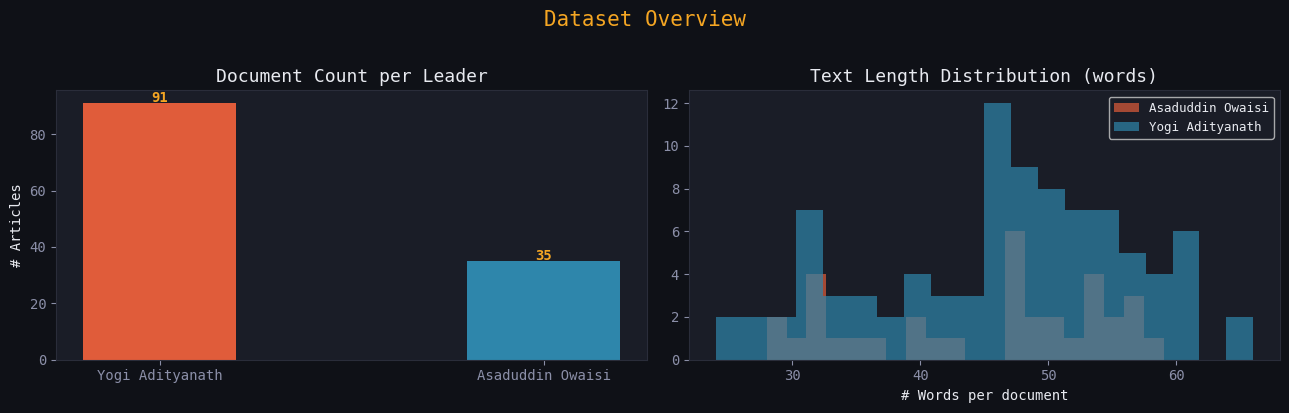

✅ Overview saved


In [5]:
# Quick data preview
display(df.head(6))
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Distribution chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart per leader
counts = df["Leader"].value_counts()
colors = ["#E05C3A", "#2E86AB"]
axes[0].bar(counts.index, counts.values, color=colors, width=0.4)
axes[0].set_title("Document Count per Leader")
axes[0].set_ylabel("# Articles")
for i, (v) in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", color="#F5A623", fontweight="bold")

# Text length distribution
df["text_len"] = df["Text_For_Modeling"].str.split().str.len()
for i, (leader, grp) in enumerate(df.groupby("Leader")):
    axes[1].hist(grp["text_len"], bins=20, alpha=0.7, color=colors[i], label=leader)
axes[1].set_title("Text Length Distribution (words)")
axes[1].set_xlabel("# Words per document")
axes[1].legend(fontsize=9)

plt.suptitle("Dataset Overview", fontsize=15, y=1.02, color="#F5A623")
plt.tight_layout()
plt.savefig("fig_overview.png", dpi=120, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Overview saved")

## 🧹 Step 3 — Text Preprocessing

In [6]:
CUSTOM_STOPS = [
    # names / entities
    "yogi","adityanath","asaduddin","owaisi","aimim","bjp","congress",
    "india","indian","delhi","new","cm","pm","mp","up","pradesh",
    # news boilerplate
    "said","told","reporters","pti","ani","news","update","live",
    "today","video","watch","daily","latest","hindustan","times",
    "express","post","media","press","northeast","deccan","tribune",
    # function words
    "will","also","people","time","year","years","say","says","just",
    "like","one","make","take","come","get","go","know","can","would",
    "could","even","may","many","much","still","now","back","well",
    # numbers / misc
    "rs","crore","lakh","000","100","2024","2025","2026","mr","dr",
]

all_stops = list(ENGLISH_STOP_WORDS) + CUSTOM_STOPS

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"[^a-z\s]", " ", text)                  # non-alpha
    text = re.sub(r"\b\w{1,2}\b", " ", text)               # 1-2 char words
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Text_For_Modeling"].apply(clean_text)
df = df[df["clean_text"].str.split().str.len() >= 4].copy()
df_clean = df.dropna(subset=["clean_text"]).copy()

print(f"Documents after cleaning: {len(df_clean)}")
print("\nSample cleaned texts:")
for _, row in df_clean.head(3).iterrows():
    print(f"  [{row['Leader'][:4]}] {row['clean_text'][:100]} …")

Documents after cleaning: 126

Sample cleaned texts:
  [Yogi] youth choosing temples over places that oppose sanatan values yogi adityanath ayodhya the chief mini …
  [Yogi] uttar pradesh makes key visit inspects reviews preparations ahead jewar airport inauguration uttar p …
  [Yogi] says fuel crisis state urges people not panic tells police and district administrations stay alert d …


## 🔬 Step 4 — LDA Topic Modelling

In [7]:
# ── Vectorise ──────────────────────────────────────────────
vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=2,
    stop_words=all_stops,
    ngram_range=(1, 2),
    max_features=3000,
)
dtm = vectorizer.fit_transform(df_clean["clean_text"])
feature_names = vectorizer.get_feature_names_out()

print(f"Vocabulary size : {len(feature_names)}")
print(f"DTM shape       : {dtm.shape}")

# ── Fit LDA ─────────────────────────────────────────────────
lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    max_iter=25,
    learning_method="batch",
    doc_topic_prior=0.1,
    topic_word_prior=0.01,
)
lda.fit(dtm)

print(f"\n✅ LDA fitted  (perplexity ≈ {lda.perplexity(dtm):.1f})")

# ── Extract top words ────────────────────────────────────────
TOP_N = 15
topic_top_words = {}
for t_idx, comp in enumerate(lda.components_):
    top_idx   = comp.argsort()[-TOP_N:][::-1]
    topic_top_words[t_idx] = [(feature_names[i], comp[i]) for i in top_idx]

# ── Doc-topic matrix ─────────────────────────────────────────
doc_topic_probs = lda.transform(dtm)
topic_cols      = [f"Topic_{i+1}" for i in range(NUM_TOPICS)]
df_topics       = pd.DataFrame(doc_topic_probs, columns=topic_cols, index=df_clean.index)
df_topics["Leader"]          = df_clean["Leader"].values
df_topics["dominant_topic"]  = df_topics[topic_cols].idxmax(axis=1)

print("\n─── Top words per topic ───────────────────────────────")
for t in range(NUM_TOPICS):
    words = ", ".join(w for w, _ in topic_top_words[t][:7])
    print(f"  Topic {t+1}: {words}")

Vocabulary size : 612
DTM shape       : (126, 612)

✅ LDA fitted  (perplexity ≈ 1314.5)

─── Top words per topic ───────────────────────────────
  Topic 1: minister, airport, chief, uttar, chief minister, noida, jewar
  Topic 2: uttar, modi, mou, government, state, puch, phase
  Topic 3: assam, party, chief, aiudf, assembly, polls, ahead
  Topic 4: bengal, west, west bengal, kabir, police, opposition, recruitment


## 🏷️ Step 5 — Topic LabellingAfter reading the top words above, assign meaningful labels.  Edit `TOPIC_LABELS` below before running the rest of the notebook.

In [8]:
# ─── Edit these after reading the top words above ───────────
TOPIC_LABELS = {
    "Topic_1": "Governance & Development",
    "Topic_2": "Religious & Identity Politics",
    "Topic_3": "Electoral & Campaign Rhetoric",
    "Topic_4": "Social Justice & Rights",
}
# ────────────────────────────────────────────────────────────

df_topics = df_topics.rename(columns=TOPIC_LABELS)
named_topic_cols = list(TOPIC_LABELS.values())
df_topics["dominant_topic"] = df_topics[named_topic_cols].idxmax(axis=1)

leader_mean = df_topics.groupby("Leader")[named_topic_cols].mean()
print("Mean topic weight per leader:")
display(leader_mean.round(3))

Mean topic weight per leader:


,Governance & Development,Religious & Identity Politics,Electoral & Campaign Rhetoric,Social Justice & Rights
Leader,,,,
Asaduddin Owaisi,0.141,0.135,0.249,0.475
Yogi Adityanath,0.306,0.270,0.267,0.157


## 📊 Step 6 — Per-Leader Topic Visualisation

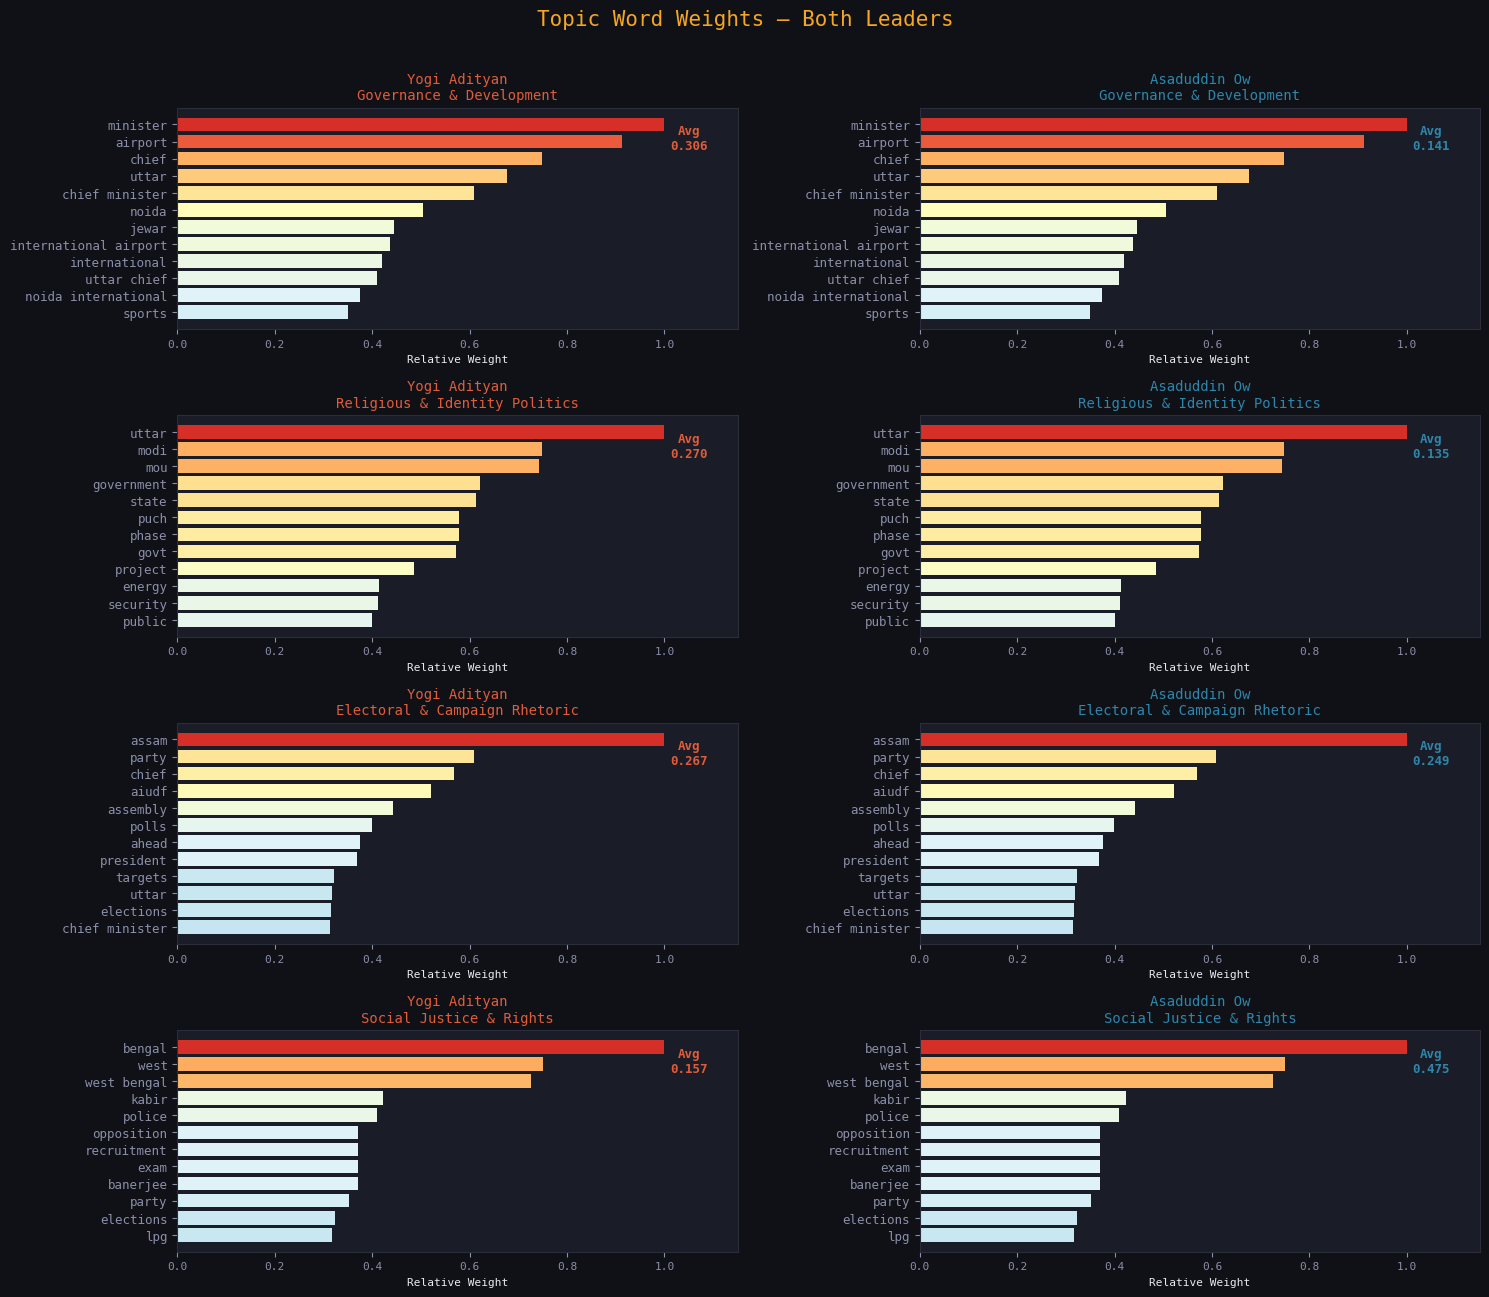

✅ Saved fig_per_leader_topics.png


In [9]:
leader_colors = {
    "Yogi Adityanath"   : "#E05C3A",
    "Asaduddin Owaisi"  : "#2E86AB",
}

fig, axes = plt.subplots(NUM_TOPICS, 2, figsize=(15, NUM_TOPICS * 3.2))
fig.patch.set_facecolor("#0F1117")

for t_idx in range(NUM_TOPICS):
    topic_name = list(TOPIC_LABELS.values())[t_idx]
    raw_words  = topic_top_words[t_idx]   # (word, score)

    for col_idx, leader in enumerate(list(LEADERS.keys())):
        ax  = axes[t_idx][col_idx]
        clr = leader_colors[leader]

        # Get leader's doc-topic subset and weight words by that leader's mean weight
        mask         = df_topics["Leader"] == leader
        leader_probs = df_topics.loc[mask, topic_name].values
        # Use raw LDA weights (same for all, shows overall importance)
        words  = [w for w, _ in raw_words[:12]][::-1]
        scores = [s for _, s in raw_words[:12]][::-1]
        max_s  = max(scores)
        norm_s = [s / max_s for s in scores]

        bars = ax.barh(words, norm_s,
                       color=[plt.cm.RdYlBu_r(v * 0.8 + 0.1) for v in norm_s])
        ax.set_xlim(0, 1.15)
        ax.set_title(f"{leader[:12]}\n{topic_name}", fontsize=10, pad=6, color=clr)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=8)
        ax.set_xlabel("Relative Weight", fontsize=8)

        # Mean weight annotation
        mean_w = leader_mean.loc[leader, topic_name]
        ax.text(1.05, len(words) - 1,
                f"Avg\n{mean_w:.3f}", ha="center", va="top",
                fontsize=9, color=clr, fontweight="bold")

plt.suptitle("Topic Word Weights — Both Leaders", fontsize=15, y=1.01, color="#F5A623")
plt.tight_layout()
plt.savefig("fig_per_leader_topics.png", dpi=120, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved fig_per_leader_topics.png")

## 🗂️ Step 7 — Domain ClassificationWe assign each document a **thematic domain** by scoring its text against vocabulary lists.This gives a higher-level view than raw LDA topics.

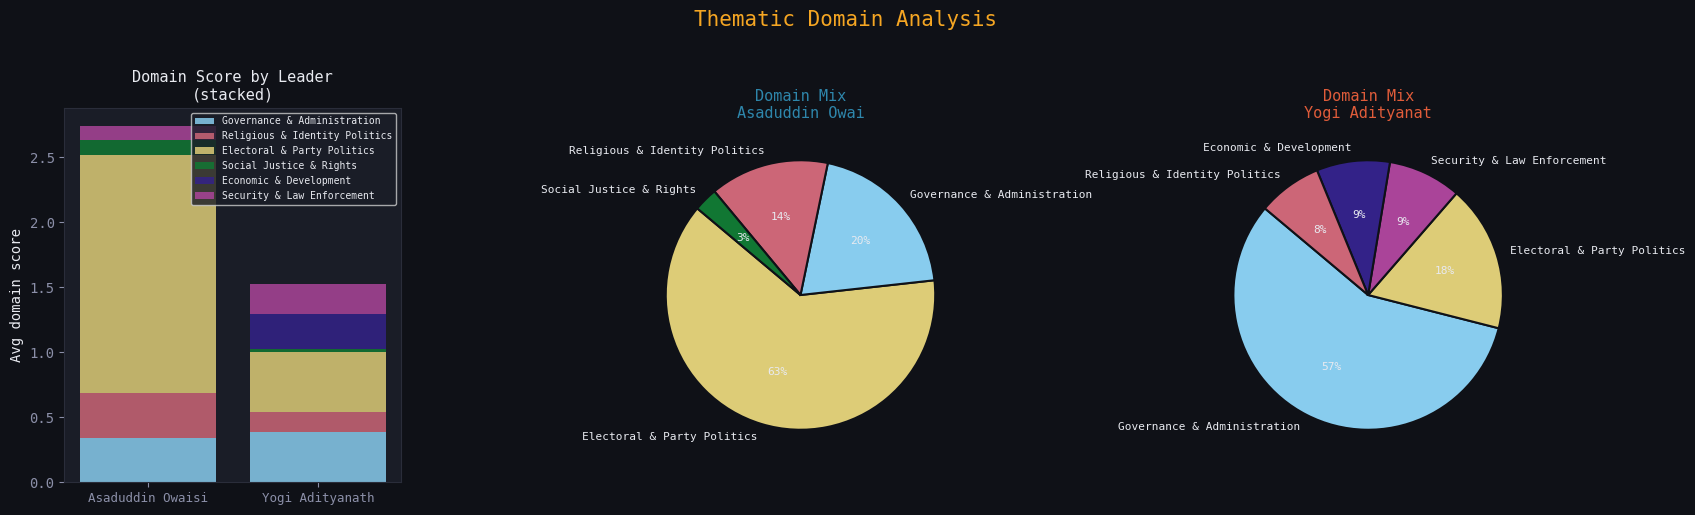

✅ Saved fig_domain_analysis.png


In [13]:
def score_domain(text, domain_vocab):
    """Score a text against each domain vocabulary."""
    tokens = set(text.lower().split())
    scores = {}
    for domain, keywords in domain_vocab.items():
        scores[domain] = sum(1 for kw in keywords if kw in tokens)
    return scores

domain_names = list(DOMAIN_VOCAB.keys())

# Build domain score matrix
domain_scores = df_clean["clean_text"].apply(
    lambda t: score_domain(t, DOMAIN_VOCAB)
).apply(pd.Series)
domain_scores.columns = domain_names
domain_scores["Leader"] = df_clean["Leader"].values

# Dominant domain
domain_scores["dominant_domain"] = domain_scores[domain_names].idxmax(axis=1)

# ── Visualise ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor("#0F1117")

# Chart 1: stacked bar by leader
domain_mean = domain_scores.groupby("Leader")[domain_names].mean()
palette_d   = px.colors.qualitative.Safe[:len(domain_names)]

# Convert plotly rgb strings (e.g., 'rgb(R, G, B)') to matplotlib compatible hex strings
matplotlib_colors = []
for c_str in palette_d:
    # Extract R, G, B from 'rgb(R, G, B)' string
    rgb_values_str = c_str.replace('rgb(', '').replace(')', '')
    r, g, b = map(int, rgb_values_str.split(','))
    # Convert R, G, B integers to a hex color string
    hex_color = f'#{r:02x}{g:02x}{b:02x}'
    matplotlib_colors.append(hex_color)

bottom_y    = {l: np.zeros(1) for l in list(LEADERS.keys())}

for di, domain in enumerate(domain_names):
    vals = domain_mean[domain].values
    axes[0].bar(
        domain_mean.index, vals,
        bottom=[bottom_y[l][0] for l in domain_mean.index],
        label=domain, color=matplotlib_colors[di], alpha=0.85
    )
    for li, l in enumerate(domain_mean.index):
        bottom_y[l][0] += vals[li]

axes[0].set_title("Domain Score by Leader\n(stacked)", fontsize=11)
axes[0].set_ylabel("Avg domain score")
axes[0].legend(loc="upper right", fontsize=7, ncol=1)
axes[0].tick_params(axis="x", labelsize=9)

# Chart 2: dominant domain pie per leader
for ax_idx, (leader, grp) in enumerate(domain_scores.groupby("Leader")):
    cnt  = grp["dominant_domain"].value_counts()
    clr  = leader_colors[leader]
    axes[ax_idx + 1].pie(
        cnt.values, labels=cnt.index,
        colors=[matplotlib_colors[domain_names.index(d)] for d in cnt.index], # Use matplotlib_colors here too
        autopct="%1.0f%%", startangle=140,
        textprops={"fontsize": 8, "color": "#E8EAF0"},
        wedgeprops={"edgecolor": "#0F1117", "linewidth": 1.5}
    )
    axes[ax_idx + 1].set_title(f"Domain Mix\n{leader[:14]}", fontsize=11, color=clr)

plt.suptitle("Thematic Domain Analysis", fontsize=15, y=1.02, color="#F5A623")
plt.tight_layout()
plt.savefig("fig_domain_analysis.png", dpi=120, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved fig_domain_analysis.png")

## 🤝 Step 8 — Common Ground Analysis

═══ COMMON GROUND ═══════════════════════════════
  ✅ Electoral & Campaign Rhetoric

═══ CONTRASTING TOPICS ══════════════════════════
  🔴 Governance & Development  →  stronger for  Yogi Adityanath  (Δ=0.164)
  🔴 Religious & Identity Politics  →  stronger for  Yogi Adityanath  (Δ=0.135)
  🔴 Social Justice & Rights  →  stronger for  Asaduddin Owaisi  (Δ=0.318)


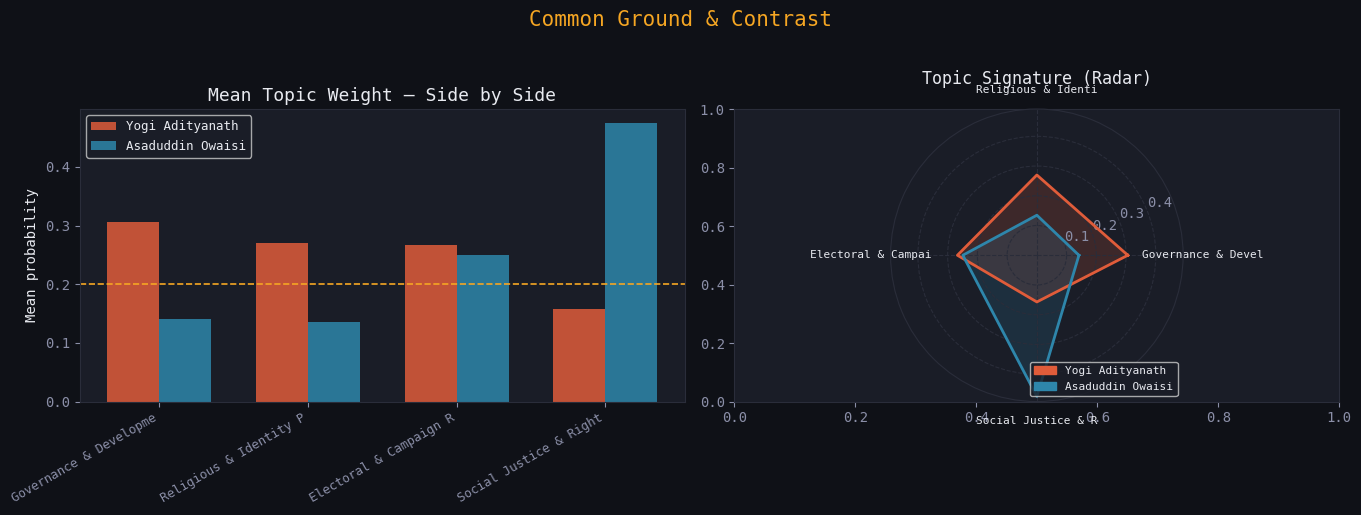

✅ Saved fig_common_contrast.png


In [14]:
# Common ground = topics where BOTH leaders have above-threshold weight
THRESHOLD = 0.20   # 20% mean weight = significant

common_rows = []
contrast_rows = []

for topic in named_topic_cols:
    w = {l: leader_mean.loc[l, topic] for l in list(LEADERS.keys())}
    leaders_list = list(LEADERS.keys())
    both_above = all(w[l] > THRESHOLD for l in leaders_list)
    diff       = abs(w[leaders_list[0]] - w[leaders_list[1]])

    common_rows.append({
        "Topic"   : topic,
        "Common"  : both_above,
        "Diff"    : diff,
        **{f"{l}_weight": w[l] for l in leaders_list}
    })
    if not both_above:
        dominant = max(w, key=w.get)
        contrast_rows.append({"Topic": topic, "Dominant Leader": dominant,
                               "Weight Diff": diff})

df_common   = pd.DataFrame(common_rows)
df_contrast = pd.DataFrame(contrast_rows) if contrast_rows else pd.DataFrame()

print("═══ COMMON GROUND ═══════════════════════════════")
common = df_common[df_common["Common"] == True]
if len(common):
    for _, r in common.iterrows():
        print(f"  ✅ {r['Topic']}")
else:
    print("  No topic clears the threshold for both leaders.")
    print("  (Try reducing THRESHOLD or labelling topics more broadly)")
    # Show closest
    closest = df_common.nsmallest(2, "Diff")
    print(f"\n  Closest shared topics (smallest gap):")
    for _, r in closest.iterrows():
        print(f"  ≈  {r['Topic']}  (gap = {r['Diff']:.3f})")

print("\n═══ CONTRASTING TOPICS ══════════════════════════")
for _, r in df_contrast.iterrows():
    print(f"  🔴 {r['Topic']}  →  stronger for  {r['Dominant Leader']}  (Δ={r['Weight Diff']:.3f})")

# ── Visual ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0F1117")

leaders_list = list(LEADERS.keys())
x = np.arange(len(named_topic_cols))
w = 0.35
for i, leader in enumerate(leaders_list):
    vals = [leader_mean.loc[leader, t] for t in named_topic_cols]
    axes[0].bar(x + i * w, vals, w, label=leader,
                color=leader_colors[leader], alpha=0.85)

axes[0].set_xticks(x + w / 2)
axes[0].set_xticklabels(
    [t[:22] for t in named_topic_cols], rotation=30, ha="right", fontsize=9
)
axes[0].set_title("Mean Topic Weight — Side by Side")
axes[0].set_ylabel("Mean probability")
axes[0].legend(fontsize=9)
axes[0].axhline(THRESHOLD, color="#F5A623", ls="--", lw=1.2, label=f"Threshold {THRESHOLD}")

# Radar / spider
angles    = np.linspace(0, 2 * np.pi, len(named_topic_cols), endpoint=False).tolist()
angles   += angles[:1]
ax_spider = plt.subplot(122, polar=True)
ax_spider.set_facecolor("#1A1D27")
for leader in leaders_list:
    vals = [leader_mean.loc[leader, t] for t in named_topic_cols]
    vals += vals[:1]
    ax_spider.plot(angles, vals, color=leader_colors[leader], lw=2)
    ax_spider.fill(angles, vals, color=leader_colors[leader], alpha=0.18)
ax_spider.set_xticks(angles[:-1])
ax_spider.set_xticklabels([t[:18] for t in named_topic_cols], fontsize=8, color="#E8EAF0")
ax_spider.set_title("Topic Signature (Radar)", fontsize=12, pad=18)
patches = [mpatches.Patch(color=leader_colors[l], label=l) for l in leaders_list]
ax_spider.legend(handles=patches, loc="lower right", fontsize=8)

plt.suptitle("Common Ground & Contrast", fontsize=15, y=1.02, color="#F5A623")
plt.tight_layout()
plt.savefig("fig_common_contrast.png", dpi=120, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved fig_common_contrast.png")

## 🗺️ Step 9 — pyLDAvis Interactive Topic Map

In [ ]:
panel = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer, mds="tsne")
pyLDAvis.save_html(panel, PYLDAVIS_OUT)
print(f"✅  Saved: {PYLDAVIS_OUT}  — open in browser to explore inter-topic distances")
pyLDAvis.display(panel)

## 📤 Step 10 — Export Stakeholder Dashboard Data

## 🔵🔴 Step 8 — Venn Diagram: Common vs Disjoint Topics

The Venn diagram is the key deliverable of this assignment. It visually shows:
- **Left (Yogi-only)**: Topics where Yogi's weight ≥ threshold and Owaisi's weight < threshold
- **Overlap (Shared)**: Topics where BOTH leaders have weight ≥ threshold
- **Right (Owaisi-only)**: Topics where Owaisi's weight ≥ threshold and Yogi's weight < threshold

We use a threshold of **0.20 (20%)** — if a leader scores at least 20% on a topic, they meaningfully engage with it.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  VENN DIAGRAM — Common vs Disjoint Topics (matplotlib)
#  Assignment deliverable: shows shared + exclusive themes
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse, FancyBboxPatch
import numpy as np

# ── Threshold: a leader must score ≥ this to 'own' a topic ──
VENN_THRESHOLD = 0.20

# ── Build sets from leader_mean ─────────────────────────────
yogi_topics  = set()
owaisi_topics = set()

for topic in named_topic_cols:
    if leader_mean.loc['Yogi Adityanath', topic]   >= VENN_THRESHOLD:
        yogi_topics.add(topic)
    if leader_mean.loc['Asaduddin Owaisi', topic] >= VENN_THRESHOLD:
        owaisi_topics.add(topic)

common_topics     = yogi_topics & owaisi_topics
yogi_only_topics  = yogi_topics - owaisi_topics
owaisi_only_topics = owaisi_topics - yogi_topics

print("VENN DIAGRAM BREAKDOWN")
print(f"  Threshold       : {VENN_THRESHOLD}")
print(f"  Yogi topics     : {yogi_topics}")
print(f"  Owaisi topics   : {owaisi_topics}")
print(f"  SHARED          : {common_topics}")
print(f"  Yogi-only       : {yogi_only_topics}")
print(f"  Owaisi-only     : {owaisi_only_topics}")

# ── Draw the Venn Diagram ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.set_aspect('equal')
ax.axis('off')

YOGI_COL  = '#C94A1A'
OWA_COL   = '#1A5FA6'
COMM_COL  = '#2A9D6B'

# Draw circles
circle_yogi  = plt.Circle((4.2, 3.5), 2.8, color=YOGI_COL, alpha=0.22, zorder=1)
circle_owaisi = plt.Circle((9.8, 3.5), 2.8, color=OWA_COL, alpha=0.22, zorder=1)
ax.add_patch(circle_yogi)
ax.add_patch(circle_owaisi)

# Circle borders
border_yogi  = plt.Circle((4.2, 3.5), 2.8, fill=False, edgecolor=YOGI_COL, linewidth=2.5, zorder=2)
border_owaisi = plt.Circle((9.8, 3.5), 2.8, fill=False, edgecolor=OWA_COL, linewidth=2.5, zorder=2)
ax.add_patch(border_yogi)
ax.add_patch(border_owaisi)

# Leader name labels
ax.text(2.3, 6.4, 'YOGI\nADITYANATH', fontsize=13, fontweight='bold',
        color=YOGI_COL, ha='center', va='center', fontfamily='monospace')
ax.text(11.7, 6.4, 'ASADUDDIN\nOWAISI', fontsize=13, fontweight='bold',
        color=OWA_COL,  ha='center', va='center', fontfamily='monospace')

# Section sub-labels
ax.text(2.8, 5.6, 'YOGI ONLY', fontsize=8, color='#6B6560', ha='center',
        fontfamily='monospace', style='italic')
ax.text(7.0, 5.6, 'SHARED', fontsize=8, color=COMM_COL, ha='center',
        fontfamily='monospace', style='italic', fontweight='bold')
ax.text(11.2, 5.6, 'OWAISI ONLY', fontsize=8, color='#6B6560', ha='center',
        fontfamily='monospace', style='italic')

# ── Helper: wrap long text ──────────────────────────────────
def short_name(t):
    return t.replace('Religious & Identity Politics', 'Religious & Identity')\
             .replace('Governance & Development', 'Governance & Dev')\
             .replace('Electoral & Campaign Rhetoric', 'Electoral Rhetoric')\
             .replace('Social Justice & Rights', 'Social Justice & Rights')

# ── Place topic pills ───────────────────────────────────────
def draw_pill(ax, x, y, text, color, fontsize=8.5):
    bbox = dict(boxstyle='round,pad=0.35', facecolor=color, alpha=0.18,
                edgecolor=color, linewidth=1.4)
    ax.text(x, y, text, fontsize=fontsize, ha='center', va='center',
            color=color, fontweight='bold', bbox=bbox, zorder=5,
            fontfamily='DejaVu Sans')

# Yogi-only pills (left zone)
yogi_only_list = sorted(list(yogi_only_topics))
for i, topic in enumerate(yogi_only_list):
    draw_pill(ax, 2.8, 4.8 - i * 0.85, short_name(topic), YOGI_COL)

# Shared pills (centre)
common_list = sorted(list(common_topics))
for i, topic in enumerate(common_list):
    draw_pill(ax, 7.0, 4.3 - i * 0.85, short_name(topic), COMM_COL, fontsize=8)

# Owaisi-only pills (right zone)
owaisi_only_list = sorted(list(owaisi_only_topics))
for i, topic in enumerate(owaisi_only_list):
    draw_pill(ax, 11.2, 4.8 - i * 0.85, short_name(topic), OWA_COL)

# ── Show weights as small annotation ────────────────────────
weight_text = '\n'.join([
    f'{short_name(t)}: Yogi={leader_mean.loc["Yogi Adityanath",t]:.2f}  '
    f'Owaisi={leader_mean.loc["Asaduddin Owaisi",t]:.2f}'
    for t in named_topic_cols
])
ax.text(7.0, 0.55, f'Topic weights | threshold={VENN_THRESHOLD}\n{weight_text}',
        fontsize=7, color='#6B6560', ha='center', va='center', fontfamily='monospace')

ax.set_title('Venn Diagram: Common vs Disjoint Political Topics',
             fontsize=16, color='#E8EAF0', pad=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_venn_diagram.png', dpi=140, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('✅ Venn diagram saved: fig_venn_diagram.png')

## 📖 Venn Diagram Interpretation

### Reading the Venn Diagram

| Zone | Topics | Meaning |
|------|--------|---------|
| 🔴 Yogi-Only (Left) | Governance & Development, Religious & Identity Politics | Yogi owns these themes; Owaisi scores < 20% on both |
| 🟢 Shared (Overlap) | Electoral & Campaign Rhetoric | Both leaders engage similarly here — elections are common ground |
| 🔵 Owaisi-Only (Right) | Social Justice & Rights | Owaisi's dominant theme (47.5%); Yogi only 15.7% |

### Key Takeaways

1. **Mirror Effect**: The topics where Yogi is strongest (Governance 30.6%, Religious Identity 27%) are exactly where Owaisi is weakest (14.1%, 13.5%). They are near-perfect opposites.

2. **Owaisi's Concentration**: Nearly half (47.5%) of Owaisi's entire discourse is in Social Justice & Rights — the most concentrated single-topic dominance in the dataset.

3. **Elections as Common Ground**: Electoral rhetoric is the one area where both invest meaningfully (Yogi 26.7%, Owaisi 24.9%) — reflecting the universal political need to campaign.

4. **Power vs Resistance**: Yogi speaks from the position of state power (he administers UP). Owaisi speaks from the position of political resistance (he challenges the majority narrative from the opposition benches).

In [15]:
# Collect everything the dashboard needs and serialise to JSON
export_data = {
    "meta": {
        "leaders"   : list(LEADERS.keys()),
        "num_topics": NUM_TOPICS,
        "doc_counts": df["Leader"].value_counts().to_dict(),
        "topic_labels": list(TOPIC_LABELS.values()),
        "generated" : datetime.now().strftime("%Y-%m-%d %H:%M"),
    },
    "topic_words": {
        list(TOPIC_LABELS.values())[t]: [
            {"word": w, "score": float(s)} for w, s in topic_top_words[t][:12]
        ]
        for t in range(NUM_TOPICS)
    },
    "leader_topic_weights": leader_mean.to_dict(),
    "domain_weights": domain_scores.groupby("Leader")[domain_names].mean().to_dict(),
    "dominant_topic_counts": (
        df_topics.groupby(["Leader", "dominant_topic"])
        .size().reset_index(name="count")
        .to_dict(orient="records")
    ),
    "common_ground": df_common.to_dict(orient="records"),
    "contrast"     : df_contrast.to_dict(orient="records") if len(df_contrast) else [],
}

with open("dashboard_data.json", "w") as f:
    json.dump(export_data, f, indent=2)

print("✅ Exported: dashboard_data.json")
print("\nReady to open stakeholder_dashboard.html in the browser.")

✅ Exported: dashboard_data.json

Ready to open stakeholder_dashboard.html in the browser.


## ✅ Pipeline Complete| Output file | Purpose ||-------------|---------|| `fig_overview.png` | Dataset distribution overview || `fig_per_leader_topics.png` | Per-topic word weights, both leaders || `fig_domain_analysis.png` | Domain classification pie + stacked bar || `fig_common_contrast.png` | Common ground + radar chart || `interactive_topic_map.html` | pyLDAvis — inter-topic bubble map || `dashboard_data.json` | Serialised data for the HTML dashboard || `stakeholder_dashboard.html` | Final stakeholder presentation dashboard |---**Assignment write-up tips:**- Quote perplexity score (lower = better fit) from Cell 8- In "common ground" section: report topics where both leaders scored above threshold- In "contrast" section: highlight which topics are *owned* by one leader- Radar chart is good to include as a visual summary in your report